In [1]:
# ============================================
# PHASE 1 MINI PROJECT — Robot Arm Simulator
# Combines: Rotation Matrices, Homogeneous Transforms,
#           Euler Angles, Quaternions, DH Parameters,
#           Forward Kinematics, Jacobian, Velocity Control
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Phase 1 MINI PROJECT -- Robot Arm Simulator ")
print("="*50)
print("Concepts : Rotation Matrices | DH Parameters | Forward Kinematics | Jacobian ")


Phase 1 MINI PROJECT -- Robot Arm Simulator 
Concepts : Rotation Matrices | DH Parameters | Forward Kinematics | Jacobian 


In [7]:
# ============================================
# CORE FUNCTIONS — All Phase 1 concepts
# ============================================

# --- Rotation Matrices (Day 2) ---
def Rx(a):
    c ,s = np.cos(a) ,np.sin(a) 
    return np.array([[1,0,0] , [0,c,-s] , [0, s,c]])

def Ry(a):
    c ,s = np.cos(a) ,np.sin(a) 
    return np.array([[c,0,s] , [0,1,0] , [-s,0,c]])

def Rz(a):
    c ,s = np.cos(a) ,np.sin(a) 
    return np.array([[c,-s,0] , [s,c,0] , [0,0,1]])

# --- Quaternions (Day 3) ---
def rotation_to_quaternion(R):
    trace = R[0,0] + R[1,1] + R[2,2]
    w = 0.5 * np.sqrt(max(0,1+ trace ))
    x = 0.5 * np.sqrt(max(0, 1 + R[0,0] - R[1,1] - R[2,2]))
    y = 0.5 * np.sqrt(max(0, 1 - R[0,0] + R[1,1] - R[2,2]))
    z = 0.5 * np.sqrt(max(0, 1 - R[0,0] - R[1,1] + R[2,2]))
    return np.array([w, x, y, z])

# ---DH parameters (Day 4) ---
def DH_transform(a, alpha, d, theta):
    ct = np.cos(theta) 
    st = np.sin(theta)
    ca = np.cos(alpha)
    sa = np.sin(alpha)
    return np.array([
        [ct, -st*ca,  st*sa, a*ct],
        [st,  ct*ca, -ct*sa, a*st],
        [0,   ct*ca,     ca,    d],
        [0,       0,      0,    1]
    ])

# --- Forward Kinematics (Day 4 + 5) ---
def forward_kinematics(thetas, L):
    """
    thetas: list of 3 joint angles in radians
    L: list of 3 link lengths
    returns: joint positions, final transform, end effector pose
    """
    T1 = DH_transform(L[0], 0, 0, thetas[0])
    T2 = DH_transform(L[1], 0, 0, thetas[1])
    T3 = DH_transform(L[2], 0, 0, thetas[2])

    T01 = T1
    T02 = T1 @ T2 
    T03 = T1 @ T2 @ T3

    positions = np.array([
        [0,0],
        [T01[0,3], T01[1,3]],
        [T02[0,3], T02[1,3]],
        [T03[0,3], T03[1,3]]
    ])

    return positions, T03       

# ---Jacobian (Day 6) ---
def compute_jacobian(thetas ,L):
    t1, t2, t3 = thetas
    L1, L2, L3 = L
    J = np.array([
        [-L1*np.sin(t1) - L2*np.sin(t1+t2) - L3*np.sin(t1+t2+t3),
         -L2*np.sin(t1+t2) - L3*np.sin(t1+t2+t3),
         -L3*np.sin(t1+t2+t3)],
        [L1*np.cos(t1) + L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3),
         L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3),
         L3*np.cos(t1+t2+t3)]
    ])
    return J

print("✅ All core functions loaded!")
print("   - Rotation matrices (Rx, Ry, Rz)")
print("   - Quaternion conversion")
print("   - DH transform")
print("   - Forward kinematics")
print("   - Jacobian")


✅ All core functions loaded!
   - Rotation matrices (Rx, Ry, Rz)
   - Quaternion conversion
   - DH transform
   - Forward kinematics
   - Jacobian


In [10]:
# ============================================
# MAIN SIMULATOR
# ============================================

def simulate_arm(thetas_deg, L, x_dot_desired=None):
    """
    Complete robot arm simulator
    
    thetas_deg : joint angles in degrees [t1, t2, t3]
    L          : link lengths [L1, L2, L3]
    x_dot_desired : desired end effector velocity [vx, vy] (optional)
    """

    # Convert to radians
    thetas =[np.radians(t) for t in thetas_deg]

    # --- Forward kinematics ---
    positions, T_final = forward_kinematics(thetas, L)

    #--- End Effector pose ---
    x = T_final[0,3]
    y = T_final[1,3]
    R = T_final[:3, :3]  # Orientation

    # --- Quaternions ---
    q = rotation_to_quaternion(R)

    # --- Jacobians --- 
    J = compute_jacobian(thetas, L)

    # Velocity control (if desired velocity is given) ---
    q_dot = None 
    if x_dot_desired is not None :
        J_pinv = np.linalg.pinv(J)
        q_dot = J_pinv @ np.array(x_dot_desired)

    # --- Print results --- 
    print("="*50)
    print("ROBOT ARM SIMULATOR — RESULTS")
    print("="*50)
    print(f"\n📐 Joint Angles: {thetas_deg} degrees")
    print(f"📏 Link Lengths: {L} meters")
    print(f"\n📍 End Effector Position:")
    print(f"   x = {round(x, 3)} m")
    print(f"   y = {round(y, 3)} m")
    print(f"\n🔄 End Effector Orientation (Quaternion):")
    print(f"   [w, x, y, z] = {np.round(q, 4)}")
    print(f"   Magnitude = {round(np.linalg.norm(q), 4)}")
    print(f"\n📊 Jacobian Matrix:")
    print(np.round(J, 3))

    if q_dot is not None:
        print(f"\n⚡ Velocity Control:")
        print(f"   Desired end effector velocity: {x_dot_desired}")
        print(f"   Required joint velocities (rad/s):")
        print(f"   θ1_dot={round(q_dot[0],3)}, θ2_dot={round(q_dot[1],3)}, θ3_dot={round(q_dot[2],3)}")

    return positions, x, y, J, q_dot      

# --- Run The SIMULATOR ---
positions, x, y, J, q_dot = simulate_arm(
    thetas_deg = [30, 45, 60],
    L          = [1.0, 0.8, 0.5],
    x_dot_desired = [0.5, 0.3]
)    

ROBOT ARM SIMULATOR — RESULTS

📐 Joint Angles: [30, 45, 60] degrees
📏 Link Lengths: [1.0, 0.8, 0.5] meters

📍 End Effector Position:
   x = 0.72 m
   y = 1.626 m

🔄 End Effector Orientation (Quaternion):
   [w, x, y, z] = [0.3827 0.     0.     0.9239]
   Magnitude = 1.0

📊 Jacobian Matrix:
[[-1.626 -1.126 -0.354]
 [ 0.72  -0.146 -0.354]]

⚡ Velocity Control:
   Desired end effector velocity: [0.5, 0.3]
   Required joint velocities (rad/s):
   θ1_dot=0.115, θ2_dot=-0.479, θ3_dot=-0.417


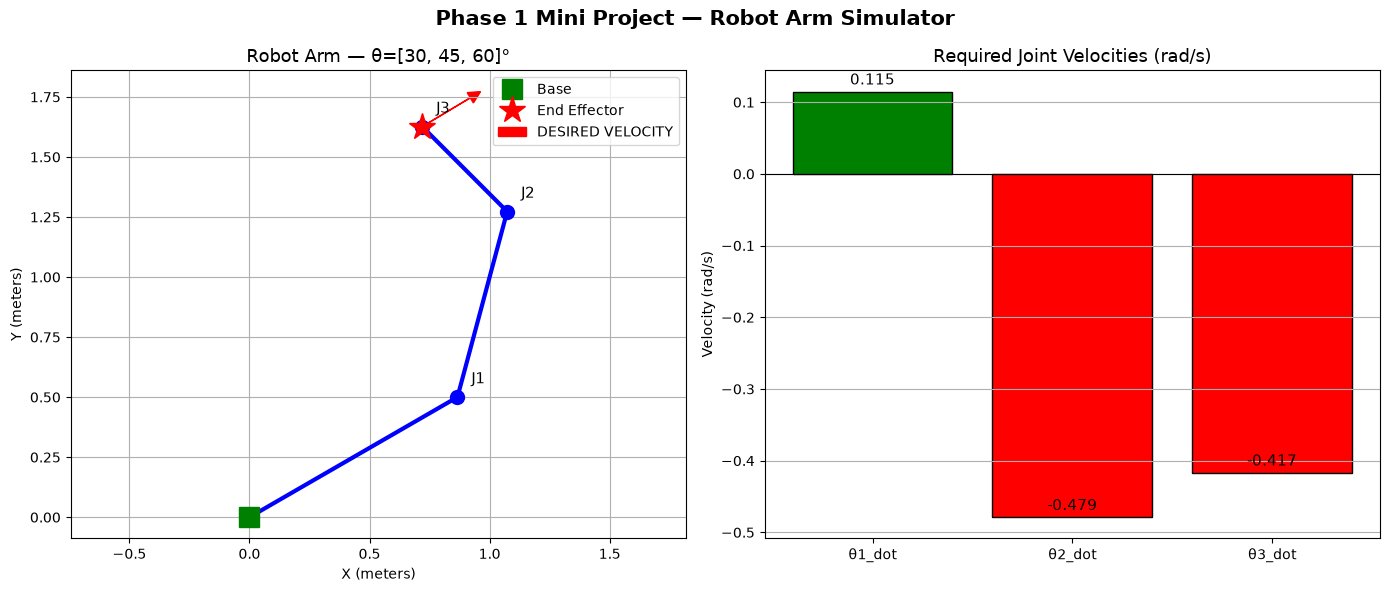

In [12]:
# ============================================
# VISUALIZATION
# ============================================

def visualize_arm(positions, x, y, q_dot, x_dot_desired, thetas_deg):
    fig, axes = plt.subplots(1, 2, figsize = (14,6))

    # --- Left plot: Robot arm ---
    ax1 = axes[0]
    ax1.plot(positions[:,0], positions[:,1], 'b-o', linewidth=3, markersize=10)
    ax1.plot(positions[0,0], positions[0,1], 'gs', markersize=15, label='Base')
    ax1.plot(positions[-1,0], positions[-1,1], 'r*', markersize=20, label='End Effector')

    # Velocity Arrow 
    if x_dot_desired is not None and q_dot is not None:
        scale = 0.4
        ax1.arrow(x,y,
                  x_dot_desired[0]*scale,
                  x_dot_desired[1]*scale,
                  head_width = 0.05, head_length= 0.05,
                  fc = 'red', ec = 'red' , label = 'DESIRED VELOCITY')
        for i,p in enumerate(positions[1:], 1):
            ax1.annotate(f'J{i}', p, textcoords = "offset points",
                        xytext = (10,10), fontsize = 11)

    ax1.set_title(f'Robot Arm — θ={thetas_deg}°', fontsize=13)
    ax1.set_xlabel('X (meters)')
    ax1.set_ylabel('Y (meters)')
    ax1.grid(True)
    ax1.axis('equal')
    ax1.legend()

# --- Right plot: Joint Velocities bar chart --- 

    ax2 = axes[1]
    if q_dot is not None:
        joints = ['θ1_dot', 'θ2_dot', 'θ3_dot']
        colors = ['green' if v >= 0 else 'red' for v in q_dot]
        ax2.bar(joints, q_dot, color=colors, edgecolor='black')
        ax2.axhline(y=0, color='black', linewidth=0.8)
        ax2.set_title('Required Joint Velocities (rad/s)', fontsize=13)
        ax2.set_ylabel('Velocity (rad/s)')
        ax2.grid(True, axis='y')

        for i, v in enumerate(q_dot):
            ax2.text(i, v + 0.01, f'{round(v,3)}', ha='center', fontsize=11)

    plt.suptitle('Phase 1 Mini Project — Robot Arm Simulator', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- Run Visualization --- 
visualize_arm(positions, x, y, q_dot, [0.5, 0.3], [30, 45, 60])